In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("E:\\portfolioRL\\TSX Merged.csv")
data = df.drop_duplicates()

C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3995897284.py:1: DtypeWarning: Columns (93,94) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("E:\\portfolioRL\\TSX Merged.csv")


C:\Users\anand\AppData\Local\Temp\ipykernel_10404\2888735809.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tic', y='volatility', data=stable_stocks, palette='viridis')


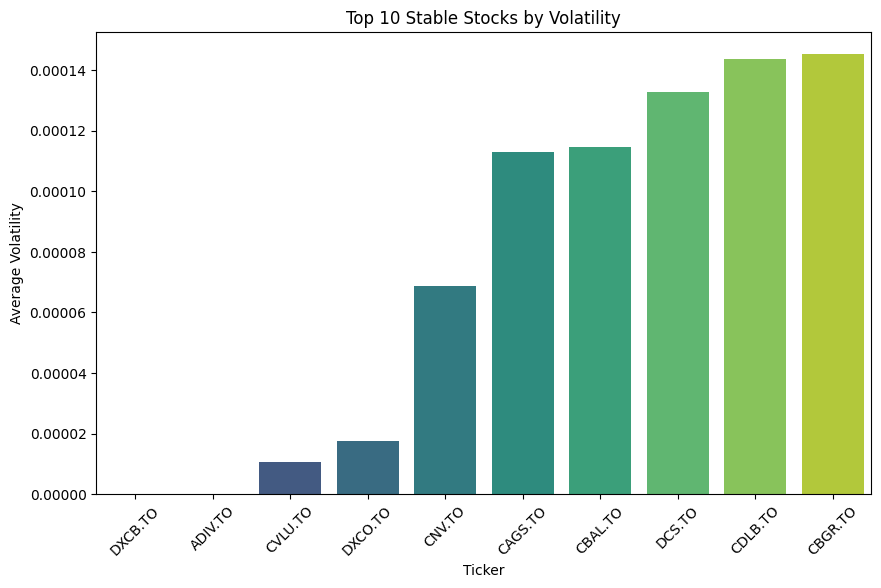

C:\Users\anand\AppData\Local\Temp\ipykernel_10404\2888735809.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sector', y='volatility', data=sector_data, palette='Spectral')


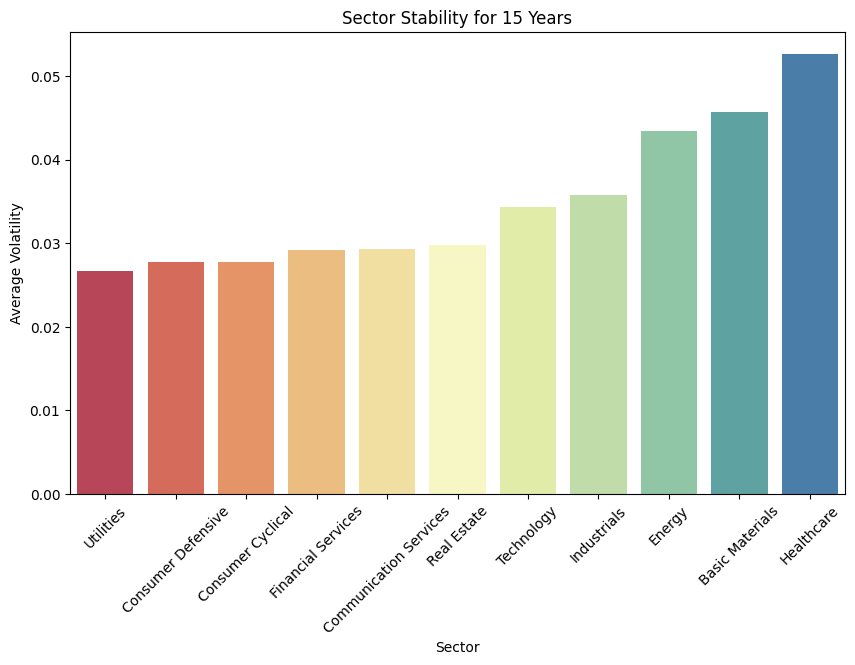

In [10]:
# Define functions to generate insights

def analyze_stock_stability(data):
    """Analyze stock stability and risk."""
    data['price_range'] = data['high'] - data['low']  # Calculate price range
    data['volatility'] = data['price_range'] / data['close']  # Calculate volatility as percentage
    stable_stocks = data.groupby('tic').agg({
        'volatility': 'mean',
        'beta': 'mean',
    }).sort_values(by='volatility', ascending=True).head(10)
    return stable_stocks

def analyze_sector_stability(data, periods):
    """Identify the most stable sector for different investment periods."""
    data['price_range'] = data['high'] - data['low']
    data['volatility'] = data['price_range'] / data['close']
    
    stable_sectors = {}
    for period in periods:
        # Filter data for the specified period
        period_data = data[data['date'] >= (pd.to_datetime(data['date']).max() - pd.DateOffset(years=period)).strftime('%Y-%m-%d')]
        
        # Group by sector and calculate average volatility
        sector_volatility = period_data.groupby('sector').agg({
            'volatility': 'mean'
        }).sort_values(by='volatility', ascending=True)
        
        stable_sectors[period] = sector_volatility
    
    return stable_sectors

# Visualization functions
def visualize_stability(stable_stocks):
    """Visualize stable stocks."""
    stable_stocks.reset_index(inplace=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='tic', y='volatility', data=stable_stocks, palette='viridis')
    plt.title('Top 10 Stable Stocks by Volatility')
    plt.xlabel('Ticker')
    plt.ylabel('Average Volatility')
    plt.xticks(rotation=45)
    plt.show()

def visualize_sector_stability(stable_sectors):
    """Visualize sector stability over different investment periods."""
    for period, sector_data in stable_sectors.items():
        sector_data.reset_index(inplace=True)
        plt.figure(figsize=(10, 6))
        sns.barplot(x='sector', y='volatility', data=sector_data, palette='Spectral')
        plt.title(f'Sector Stability for {period} Years')
        plt.xlabel('Sector')
        plt.ylabel('Average Volatility')
        plt.xticks(rotation=45)
        plt.show()

# Run analyses
stability_insights = analyze_stock_stability(data)
investment_periods = [15]  # Define investment periods in years
sector_stability_insights = analyze_sector_stability(data, investment_periods)

# Visualize results
visualize_stability(stability_insights)
visualize_sector_stability(sector_stability_insights)


C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3845541704.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['date'] = pd.to_datetime(healthcare_data1['date'])
C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3845541704.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['price_difference'] = healthcare_data1['tic'].map(baseline_prices)
C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3845541704.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of

            date          close           high        low       open  volume  \
21288 2004-12-01    3726.000000    3780.000000    3618.00    3618.00      15   
21303 2004-12-01      12.962213      18.299999      17.82      17.85  531000   
21342 2004-12-01       1.950000       2.050000       1.95       2.00    1200   
21344 2004-12-01  459000.000000  462000.000000  450000.00  451800.00       1   
21360 2004-12-01       0.707200       1.400000       1.34       1.34  352200   

           tic  day                                  industry      sector  \
21288   APS.TO    2                             Biotechnology  Healthcare   
21303   BHC.TO    2  Drug Manufacturers - Specialty & Generic  Healthcare   
21342   CPH.TO    2  Drug Manufacturers - Specialty & Generic  Healthcare   
21344  CSCI.TO    2                             Biotechnology  Healthcare   
21360   EDT.TO    2                    Diagnostics & Research  Healthcare   

       ...  fundFamily  legalType  yield  threeYearAvera

<Figure size 1200x800 with 0 Axes>

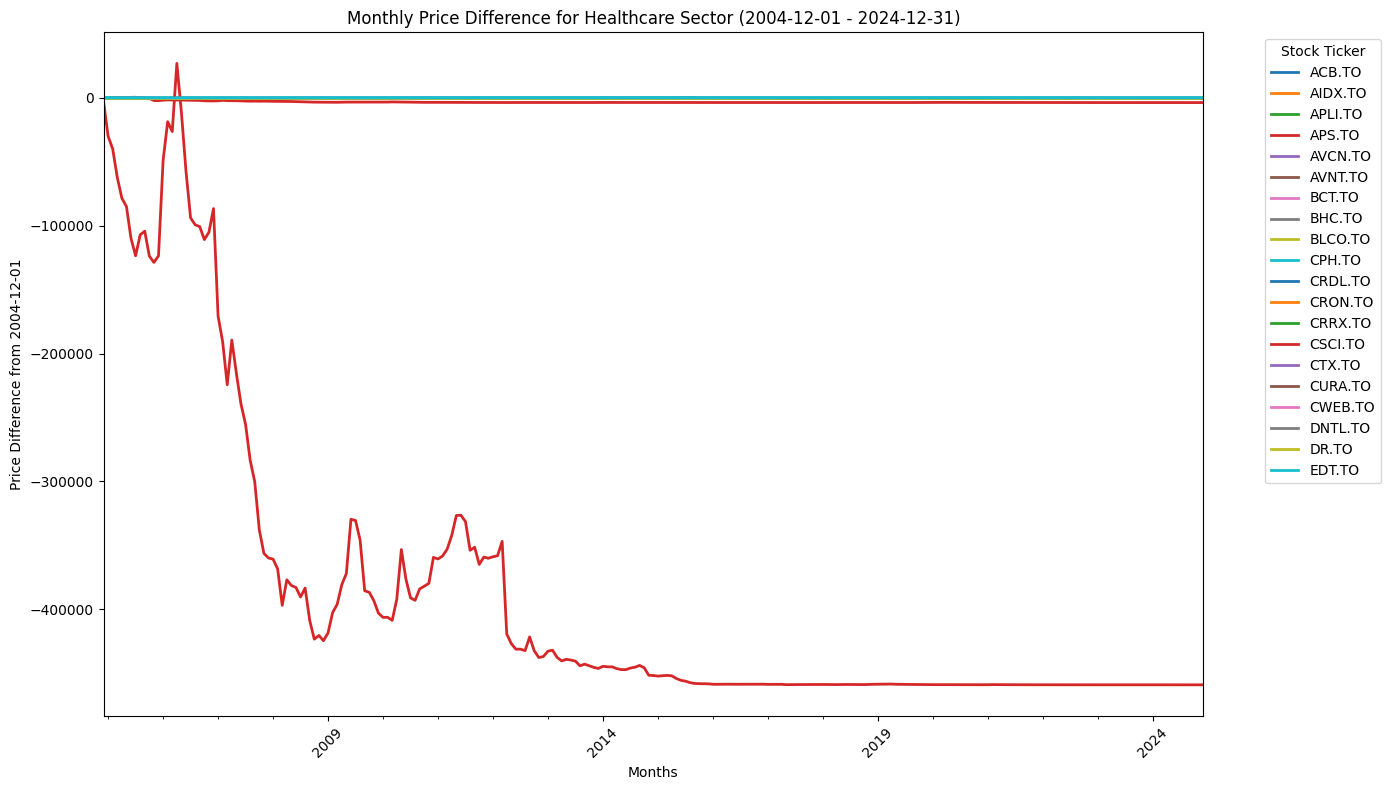

C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3845541704.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['date'] = pd.to_datetime(healthcare_data1['date'])
C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3845541704.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  healthcare_data1['price_difference'] = healthcare_data1['tic'].map(baseline_prices)
C:\Users\anand\AppData\Local\Temp\ipykernel_10404\3845541704.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of

             date      close   high    low   open  volume      tic  day  \
859729 2022-12-01  17.799999  17.90  17.00  17.40  305080   ACB.TO    3   
859742 2022-12-01   0.540000   0.54   0.54   0.54       0  AIDX.TO    3   
859756 2022-12-01   0.050000   0.05   0.05   0.05   19729  APLI.TO    3   
859757 2022-12-01  13.500000  13.65  13.50  13.50     420   APS.TO    3   
859776 2022-12-01   0.320000   0.33   0.32   0.33   43100  AVCN.TO    3   

                                        industry      sector  ...  fundFamily  \
859729  Drug Manufacturers - Specialty & Generic  Healthcare  ...         NaN   
859742                   Medical Care Facilities  Healthcare  ...         NaN   
859756                             Biotechnology  Healthcare  ...         NaN   
859757                             Biotechnology  Healthcare  ...         NaN   
859776  Drug Manufacturers - Specialty & Generic  Healthcare  ...         NaN   

        legalType  yield  threeYearAverageReturn  fiveYearAver

<Figure size 1200x800 with 0 Axes>

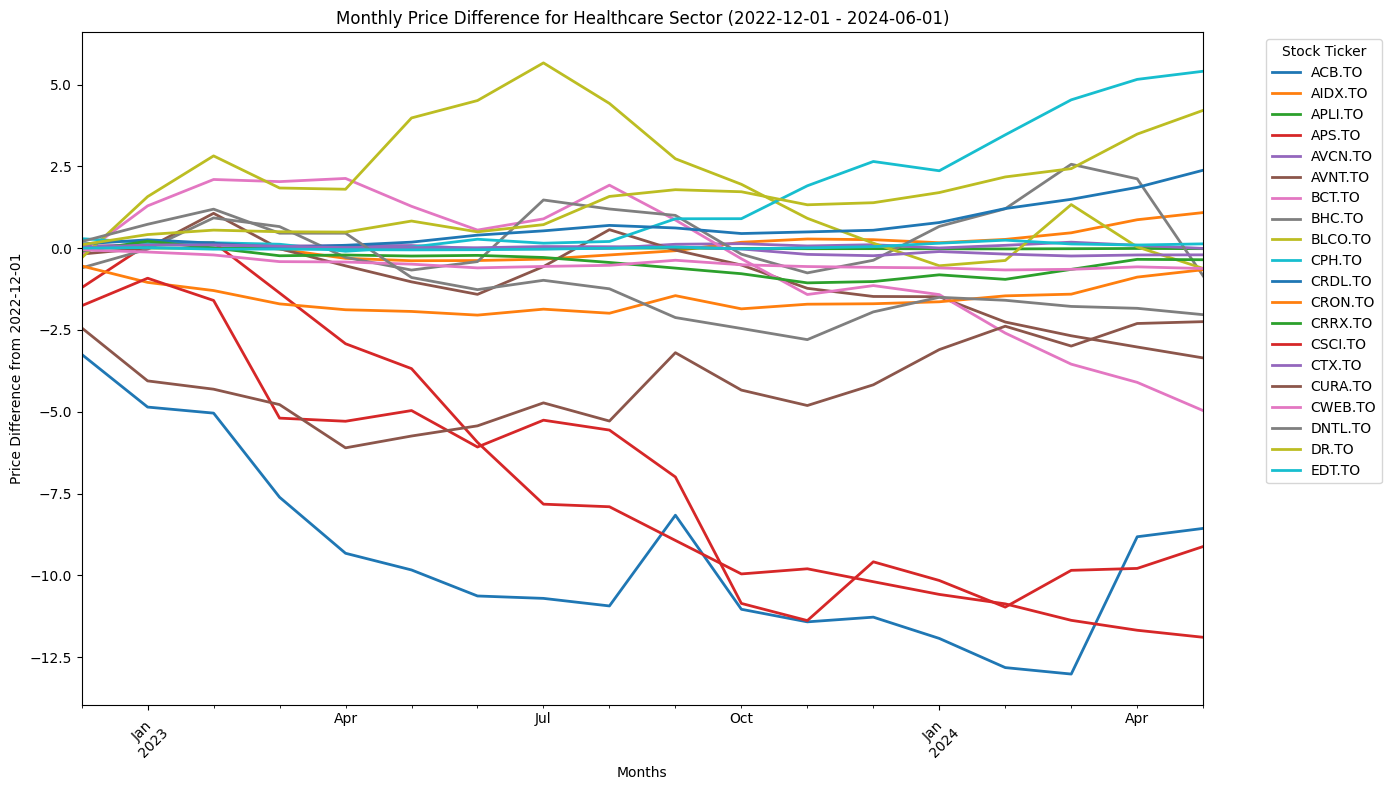

In [11]:
healthcare_data=data[(data['sector']=="Healthcare")] ###&(data['date'] >= '2004-12-01') & (data['date'] <= '2023-06-01')]
healthcare_data.sort_values(by='date')
def calculate_price(startdate,enddate): 
  # Get baseline prices for December 1, 2022
     healthcare_data1=healthcare_data[(healthcare_data['date'] >= startdate) & (healthcare_data['date'] <= enddate)]

     healthcare_data1['date'] = pd.to_datetime(healthcare_data1['date'])
     baseline_prices = (
         healthcare_data1[healthcare_data1['date'] == startdate]
         .groupby('tic')['close']
         .first()
         .to_dict()
         )
     print(healthcare_data1.head())
     # Calculate price difference from baseline
     healthcare_data1['price_difference'] = healthcare_data1['tic'].map(baseline_prices)
     healthcare_data1['price_difference'] = healthcare_data1['close'] - healthcare_data1['price_difference']

    # Extract year and month for grouping
     healthcare_data1['year_month'] = healthcare_data1['date'].dt.to_period('M')

    # Aggregate by month for each stock
     monthly_diff = healthcare_data1.groupby(['year_month', 'tic'])['price_difference'].mean().reset_index()

    # Pivot data for line plot
     pivot_data = monthly_diff.pivot(index='year_month', columns='tic', values='price_difference')

    # Ensure numeric data and handle missing values
     pivot_data = pivot_data.apply(pd.to_numeric, errors='coerce').fillna(0)

    # Debugging: Check the structure of pivot_data
     print(pivot_data.head())
     # Plot the line graph
     plt.figure(figsize=(12, 8))
     pivot_data.plot(kind='line', figsize=(14, 8), linewidth=2)
     plt.title('Monthly Price Difference for Healthcare Sector ('+startdate+' - '+enddate+')')
     plt.xlabel('Months')
     plt.ylabel('Price Difference from '+startdate)
     plt.xticks(rotation=45)
     plt.legend(title='Stock Ticker', bbox_to_anchor=(1.05, 1), loc='upper left')
     plt.tight_layout()
     plt.show()

calculate_price('2004-12-01','2024-12-31')
calculate_price('2022-12-01','2024-06-01')
